# Explaining CNN's Assignment 3

Convolutional Neural Networks (CNNs) make predictions by learning hierarchical feature representations. Early layers detect simple patterns like edges and textures, while deeper layers combine these into higher level concepts such as object parts and full objects. However, we cannot rely on standard accuracy metrics as they do not reveal why a model makes a specific prediction. Explainability methods explain this by producing visual attributions that highlight which parts of an input image most influenced the model’s decision.

In the following assignment and code below, we use two techniques, Integrated Gradients and Grad-CAM, which provide explanations at different levels of detail.

**Integrated Gradients** attributes a model’s prediction to individual input pixels by comparing the input image to a baseline image. The baseline represents the absence of features, and the method computes how the model’s output changes as the input is gradually transformed from the baseline to the actual image. It integrates gradients of the output with respect to the input along this path. The resulting attribution map assigns importance scores to each pixel, indicating how much each pixel contributed to the final prediction.

For the intuition towards this technique, you can think of it as if a pixel strongly affects the prediction, changing it along the path from baseline to input will significantly change the output, resulting in a high attribution value. Knowing this, an obvious limitation arises since this technique is sensitive to the choice of baseline. An uninformative or poorly chosen baseline can produce misleading attributions, and the method can be computationally expensive due to the need for multiple gradient evaluations.

**Grad-CAM** provides a coarser, spatial explanation by using gradients flowing into a chosen convolutional layer (usually the last one). Instead of looking at individual pixels, it examines feature maps, which represent higher level visual patterns learned by the CNN. The gradients of the predicted class score are used to weight these feature maps, producing a heatmap that highlights the most important regions in the image for the model’s decision.

For the intuition towards this technique, you can think of it as if a spatial region strongly influences the class score, the feature maps activated in that region will receive higher gradient weights, producing a strong heatmap response. The limitation to this is that it is low resolution because it operates on deep feature maps rather than raw pixels. As a result, it may highlight the correct region but not precisely localize fine details.

How do these two techniques compare? Well, Integrated Gradients provides fine grained, pixel level attribution. The Grad-CAM on the other hand offers a coarse, region-level explanation. When both methods agree (ie: focusing on the animal’s head or body), it increases confidence that the model is learning meaningful features. When they disagree or focus on background elements, it may indicate dataset bias or just bad data in general.

In [1]:
# IMPORT MAYHEM (SETUP)

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from captum.attr import IntegratedGradients, LayerGradCam

In [2]:
# DATASET, MODEL, & DEVICE

ds = load_dataset("pantelism/cats-vs-dogs")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SmallConvNet(nn.Module):
    def __init__(self, dropout = True):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)


model = SmallConvNet().to(device)
model.load_state_dict(torch.load("cats_and_dogs_small.pth", map_location = device))
model.eval()

SmallConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=6272, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [3]:
# DATA LOADER & TRANSFORMS

IMG_SIZE = 150
BATCH_SIZE = 1

basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])


class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img = sample["image"].convert("RGB")
        label = float(sample["label"])
        return self.transform(img), label


test_loader = DataLoader(
    CatsDogsDataset(ds["test"], basic_tf),
    batch_size = 1,
    shuffle = True
)

In [4]:
# COLLECTING EXAMPLES

correct, wrong = [], []

for imgs, labels in test_loader:
    imgs, labels = imgs.to(device), labels.to(device)

    with torch.no_grad():
        probs = torch.sigmoid(model(imgs))
        preds = (probs > 0.5).long()

    for i in range(len(imgs)):
        if len(correct) < 3 and preds[i] == labels[i]:
            correct.append((imgs[i], labels[i].item(), preds[i].item()))
        elif len(wrong) < 1 and preds[i] != labels[i]:
            wrong.append((imgs[i], labels[i].item(), preds[i].item()))

    if len(correct) == 3 and len(wrong) == 1:
        break

In [5]:
# EXPLAINERS

ig = IntegratedGradients(model)

def compute_ig(img):
    img = img.unsqueeze(0).to(device)
    baseline = torch.zeros_like(img)
    return ig.attribute(img, baselines = baseline).squeeze(0)


target_layer = model.features[9]
gradcam = LayerGradCam(model, target_layer)

def compute_gradcam(img):
    img = img.unsqueeze(0).to(device)

    attr = gradcam.attribute(img)

    attr = F.interpolate(
        attr,
        size = (150, 150),
        mode = "bilinear",
        align_corners = False
    )

    return attr.squeeze(0)


def show(img, title = ""):
    img = img.detach().cpu().permute(1,2,0).numpy()
    img = img * 0.5 + 0.5
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

def overlay(img, heatmap, title = ""):
    img = img.detach().cpu().permute(1,2,0).numpy()
    img = img * 0.5 + 0.5

    heatmap = heatmap.detach().cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)

    plt.imshow(img)
    plt.imshow(heatmap, cmap = "jet", alpha=0.5)
    plt.title(title)
    plt.axis("off")


def plot_explanation(img, label, pred, title = ""):
    plt.figure(figsize = (12,4))

    # ORIGINAL
    plt.subplot(1,3,1)
    show(img, f"Label = {label}, Pred = {pred}")

    # IG OVERLAY
    plt.subplot(1,3,2)
    ig_map = compute_ig(img).abs().sum(dim = 0)
    overlay(img, ig_map, "Integrated Gradients")

    # GRAD-CAM OVERLAY
    plt.subplot(1,3,3)
    gc_map = compute_gradcam(img).squeeze()
    overlay(img, gc_map, "Grad-CAM")

    plt.suptitle(title)
    plt.show()

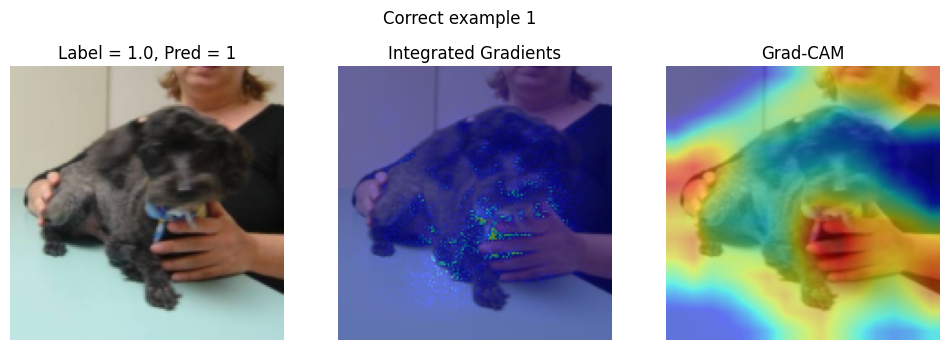

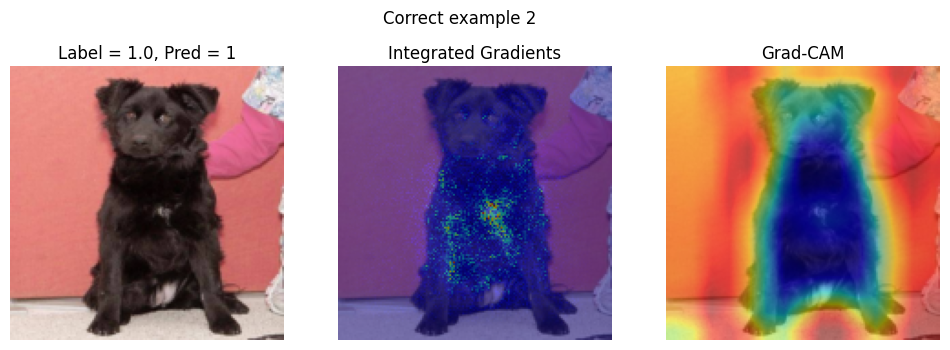

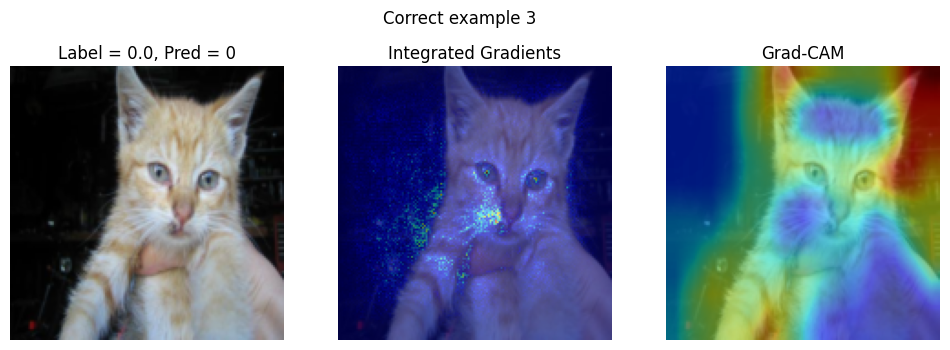

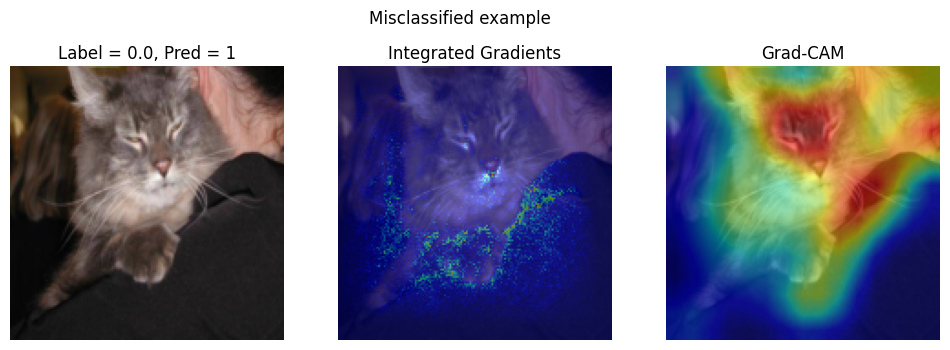

In [6]:
# SUBMISSION 

for i in range(3):
    img, label, pred = correct[i]
    plot_explanation(img, label, pred, f"Correct example {i+1}")

img, label, pred = wrong[0]
plot_explanation(img, label, pred, "Misclassified example")